# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [8]:
import pandas as pd
import numpy as np
import pyreadr # Zum Einlesen von .rda Dateien
import sys
import os
import matplotlib.pyplot as plt

# Fasse den übergeordneten Ordner ins Visier, damit Python das "python/" Verzeichnis als Modul (Package) erkennt
sys.path.append(os.path.abspath('..'))

# Jetzt können wir es sicher als Modul importieren
np.random.seed(999)  # Für Reproduzierbarkeit
from python.disco import DiSCo

## 1. Dube (2019) Daten laden
Wir laden die Daten aus dem R-Package `data/dube.rda`. Laut der Vignette wird `state=2` als Treatment betrachtet und `t0=2003`.

In [9]:
# Lade die originale R-Datei
result = pyreadr.read_r('../data/dube.rda')
df_raw = result['dube']

# Das R-Package erwartet die Spalten id_col, time_col, y_col.
# In dube.rda sind die Spalten fips (state), year und adj0contpov (income).
df = df_raw.copy()
df = df.rename(columns={
    'fips': 'id_col',
    'year': 'time_col',
    'adj0contpov': 'y_col'
})

print(f"Datensatz geladen: {len(df)} Zeilen")
df.head()

Datensatz geladen: 652870 Zeilen


,time_col,id_col,y_col
0,1998.0,1.0,2.791217
1,1998.0,1.0,0.165951
2,1998.0,1.0,1.674730
3,1998.0,1.0,2.088006
4,1998.0,1.0,3.639715


In [10]:
df['id_col'].unique()

array([ 1.,  2.,  4.,  5.,  8., 13., 16., 18., 19., 20., 21., 22., 24.,
       26., 28., 29., 30., 31., 32., 33., 35., 37., 38., 39., 40., 42.,
       45., 46., 47., 48., 49., 51., 54., 56.])

## 2. DiSCo Modell initialisieren und fitten
Wir rufen nun unser `DiSCo`-Modell auf. Für diesen Test verwenden wir eine geringere Anzahl an Ziehungen (`M=100`) und 1 CPU-Kern (`num_cores=1`), da der Datensatz sehr klein ist.

In [11]:
print("Initialisiere DiSCo mit Dube-Daten...")
disco_model = DiSCo(
    df=df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target=2,     # FIPS = 2 (Alaska) als Treatment
    t0=2003,             # Treatment im Jahr 2003
    M=1000,              # Monte Carlo Draws 
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    q_max=0.9            # Entspricht den Parametern in der Vignette
)

result = disco_model.fit()

# Ausgabe der wichtigsten 5 Gewichte (ungleich null)
weight_series = pd.Series(disco_model.weights_opt, index=disco_model.controls_id)
print("\nHöchstgewichtete Kontroll-Einheiten:")
print(weight_series[weight_series > 0.01].sort_values(ascending=False).head(5))

Initialisiere DiSCo mit Dube-Daten...

Höchstgewichtete Kontroll-Einheiten:
39.0    0.181478
26.0    0.094198
45.0    0.092585
51.0    0.089025
20.0    0.082201
dtype: float64


In [5]:
print(weight_series[weight_series > 0.01].sort_values(ascending=False).head(10))

39.0    0.181478
26.0    0.094198
45.0    0.092585
51.0    0.089025
20.0    0.082201
24.0    0.053250
37.0    0.051769
29.0    0.051669
4.0     0.050971
13.0    0.046772
dtype: float64


## Inference

Now let's compute confidence intervals and permutation tests.

In [7]:
from inference import permutation_test

# Fast evaluation to save time in notebook (e.g. fewer permutations or M)
# The full run would take M=1000 and M_boot=1000, here we might do fewer.
M_permut_jobs = 1 # All cores

print("Running permutation test...")
# Note: permutation test expects the period results and T0
res_perm = permutation_test(list(result.values()), T0=int(disco_model.T0_idx-1), evgrid=disco_model.evgrid, num_cores=M_permut_jobs, M=1000)
print(f"p-value: {res_perm['p_overall']}")

Running permutation test...
Calculating 33 permutations using 1 jobs...
All placebo permutations finished successfully!
p-value: 0.7352941176470589


Now, let's run the main method including bootstrap confidence intervals.
We will initialize the model with `CI=True` and run it again. In practice, `M` (the number of evaluations in the solver) and `G` (the grid size) could be larger for more precision.

In [7]:
from disco import DiSCo

# Re-run with CI=True to compute bootstrap confidence intervals
disco_model_ci = DiSCo(df=df, id_col='id_col', time_col='time_col', y_col='y_col', 
                       t0=2003, id_col_target=2, 
                       G=1000, M=1000, # Lower M for fast demonstration
                       CI=True, cl=0.95, B=100, num_cores=-1, simplex=True, q_max=0.9)

print("Fitting model with Bootstrapping...")
result_ci = disco_model_ci.fit()
print("Model fitting complete!")

Fitting model with Bootstrapping...
Beginning Bootstrap replications...
Bootstrap replication 1/100...
Bootstrap replication 2/100...
Bootstrap replication 3/100...
Bootstrap replication 4/100...
Bootstrap replication 5/100...
Bootstrap replication 6/100...
Bootstrap replication 7/100...
Bootstrap replication 8/100...
Bootstrap replication 9/100...
Bootstrap replication 10/100...
Bootstrap replication 11/100...
Bootstrap replication 12/100...
Bootstrap replication 13/100...
Bootstrap replication 14/100...
Bootstrap replication 15/100...
Bootstrap replication 16/100...
Bootstrap replication 17/100...
Bootstrap replication 18/100...
Bootstrap replication 19/100...
Bootstrap replication 20/100...
Bootstrap replication 21/100...
Bootstrap replication 22/100...
Bootstrap replication 23/100...
Bootstrap replication 24/100...
Bootstrap replication 25/100...
Bootstrap replication 26/100...
Bootstrap replication 27/100...
Bootstrap replication 28/100...
Bootstrap replication 29/100...
Bootstrap

In [8]:
# Gesamtgewichte ansehen (wie beim ersten Modell)
weight_series_ci = pd.Series(disco_model_ci.weights_opt, index=disco_model_ci.controls_id)

print("Höchstgewichtete Kontroll-Einheiten im CI-Modell:")
print(weight_series_ci[weight_series_ci > 0.01].sort_values(ascending=False).head(10))

Höchstgewichtete Kontroll-Einheiten im CI-Modell:
39.0    0.181478
26.0    0.094198
45.0    0.092585
51.0    0.089025
20.0    0.082201
24.0    0.053250
37.0    0.051769
29.0    0.051669
4.0     0.050971
13.0    0.046772
dtype: float64


## Treatment Effect Analysis (TEA)

Next we compute the treatment effects, integrating the results from the `DiSCo` fit, including confidence intervals and plotting.

In [9]:
from python.tea import DiSCoTEA

# Switch to CDF difference to match the R plot ('CDF Change' vs 'Y')
tea_obj = DiSCoTEA(disco_model_ci, agg="cdfDiff", graph=True)

# Print a summary of the aggregated treatment effects (with CI)
print(tea_obj.summary())


Aggregation Method: cdfDiff
Confidence Level: 95.0%
Sample Size: N=587475, J=7

 Time  X_from  X_to  Effect  Std. Error  CI_Lower_95%  CI_Upper_95%
 2003     0.0   0.9  0.0014      0.0055        -0.008         0.017
 2004     0.0   0.9  0.0023      0.0063        -0.010         0.016
None


With `tea_obj` initialized based on bootstrap iterations, the object contains variables to evaluate changes over the quantile grid.

Let's see the aggregate treatment effects across periods and confidence bounds in Pandas DataFrame form:

In [10]:
print("Aggregated Results DataFrame:")
display(tea_obj.agg_df)

Aggregated Results DataFrame:


,Time,X_from,X_to,Effect,Std. Error,CI_Lower_95%,CI_Upper_95%
0,2003,0.0,0.9,0.0014,0.0055,-0.008,0.017
1,2004,0.0,0.9,0.0023,0.0063,-0.010,0.016


Lastly, let's create a graph resembling the distributional effects visualized in R `plot(tea_obj)`:

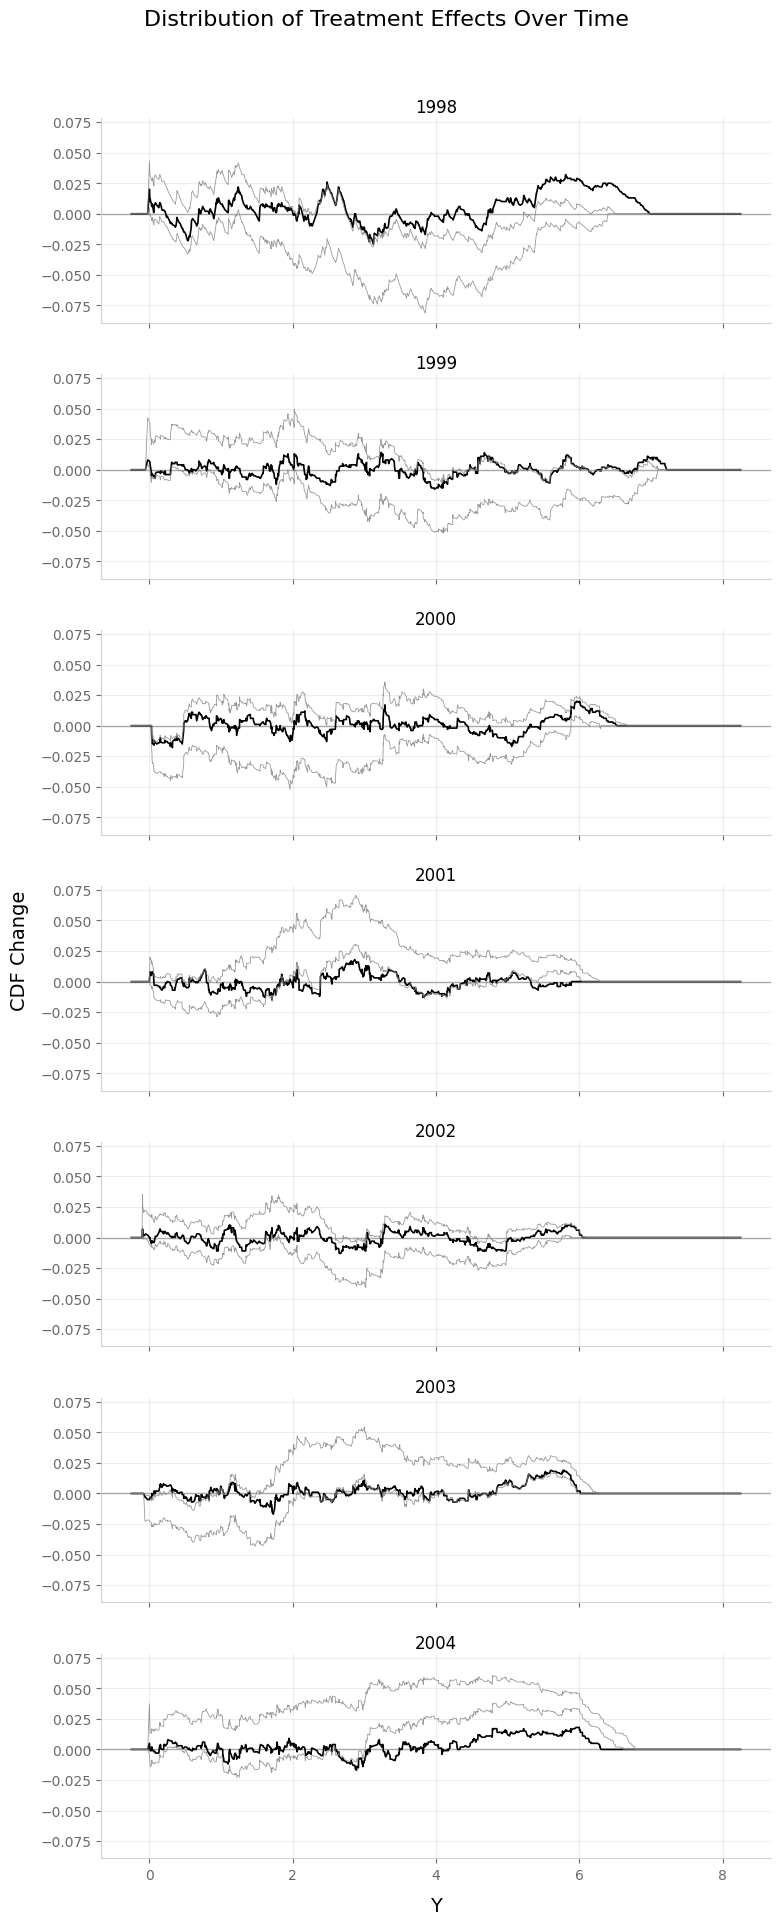

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the Treatment Effects as facets over time, mirroring the R ggplot2 output.
if tea_obj.plot and tea_obj.plot.get('treats'):
    treats = tea_obj.plot['treats']
    grid = tea_obj.plot['grid']
    t_keys = sorted(list(treats.keys()))
    
    # In DiSCo object, keys might be years directly or numeric indices.
    # Since tea.py now parses time based on results_periods indices mixed with df.time_col,
    # the keys in treats are typically the actual years directly (e.g. 1998, 1999) 
    # if t_min was correctly evaluated.
    years = t_keys
    n_periods = len(t_keys)
    
    # Dynamically determine the y-axis bounds based on all values (main effect + CI)
    all_vals = []
    for t_idx in t_keys:
        all_vals.extend(np.atleast_1d(treats[t_idx]))
        if tea_obj.plot.get('CI') and 'ci_lower' in tea_obj.plot and t_idx in tea_obj.plot['ci_lower']:
            all_vals.extend(np.atleast_1d(tea_obj.plot['ci_lower'][t_idx]))
            all_vals.extend(np.atleast_1d(tea_obj.plot['ci_upper'][t_idx]))
    
    # 5% padding on Y limit so extreme CI bounds don't touch edges
    y_min, y_max = np.min(all_vals), np.max(all_vals)
    y_pad = (y_max - y_min) * 0.05
    if y_pad == 0: y_pad = 0.01
    dyn_ylim = [y_min - y_pad, y_max + y_pad]
    
    # R plot is very tall to accommodate the facets cleanly
    fig, axes = plt.subplots(n_periods, 1, figsize=(8, 2.8 * n_periods), sharex=True, sharey=True)
    if n_periods == 1:
        axes = [axes]
        
    # Common title
    fig.suptitle("Distribution of Treatment Effects Over Time", fontsize=16, y=0.98)
    
    for i, t_idx in enumerate(t_keys):
        ax = axes[i]
        year = years[i]
        effect = treats[t_idx]
        
        # Add horizontal zero line
        ax.axhline(0, color="darkgrey", lw=1)
        
        # Plot main effect as black line
        if np.atleast_1d(effect).shape[0] == len(grid):
            # In some setups effect curve is step-like, but R plots it with standard lines
            ax.plot(grid, effect, color="black", lw=1.2)
            
        # Plot CI as thin grey lines 
        if tea_obj.plot.get('CI') and 'ci_lower' in tea_obj.plot and t_idx in tea_obj.plot['ci_lower']:
            ci_l = np.atleast_1d(tea_obj.plot['ci_lower'][t_idx])
            ci_u = np.atleast_1d(tea_obj.plot['ci_upper'][t_idx])
            
            if ci_l.shape[0] == len(grid):
                ax.plot(grid, ci_l, color="grey", lw=0.6, alpha=0.8)
                ax.plot(grid, ci_u, color="grey", lw=0.6, alpha=0.8)
        
        # Style clean up (similar to ggplot theme_minimal in R)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('lightgrey')
        ax.spines['bottom'].set_color('lightgrey')
        ax.grid(alpha=0.4, color='lightgray', linestyle='-')
        ax.tick_params(axis='both', colors='dimgrey', labelsize=10)
        
        # Subplot title for the year
        # Display as integer if possible
        year_str = str(int(year)) if year == int(year) else str(year)
        ax.set_title(year_str, fontsize=12, pad=4)
        
    # Common labels to match R Plot precisely
    agg_type = tea_obj.plot.get('agg', 'quantileDiff')
    label_x = "Y" if agg_type == 'cdfDiff' else "Quantile"
    label_y = "CDF Change" if agg_type == 'cdfDiff' else "Quantile Difference"
    
    axes[-1].set_xlabel(label_x, fontsize=14, labelpad=10)
    
    # Use fig.text to place a common Y label perfectly centered
    fig.text(0.03, 0.5, label_y, va='center', rotation='vertical', fontsize=14)
    
    # Dynamic Y limits to ensure nothing is hardcoded
    plt.ylim(dyn_ylim)
    
    # Adjust layout to leave space for titles and labels
    plt.tight_layout(rect=[0.06, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.25) # Give spacing between facets
    
    plt.show()

In [12]:
# Analyze the CI bounds and effects to see what went wrong
for t in tea_obj.plot['treats']:
    eff = tea_obj.plot['treats'][t]
    if tea_obj.plot.get('CI'):
        cil = tea_obj.plot['ci_lower'][t]
        ciu = tea_obj.plot['ci_upper'][t]
        print(f"Period {t}: Effect min={eff.min():.3f}, max={eff.max():.3f}")
        print(f"         CI lower min={cil.min():.3f}, max={cil.max():.3f}")
        print(f"         CI upper min={ciu.min():.3f}, max={ciu.max():.3f}")


Period 1998: Effect min=-0.025, max=0.032
         CI lower min=-0.082, max=0.005
         CI upper min=-0.032, max=0.043
Period 1999: Effect min=-0.016, max=0.014
         CI lower min=-0.052, max=0.005
         CI upper min=-0.010, max=0.049
Period 2000: Effect min=-0.018, max=0.020
         CI lower min=-0.052, max=0.008
         CI upper min=-0.014, max=0.036
Period 2001: Effect min=-0.015, max=0.018
         CI lower min=-0.029, max=0.031
         CI upper min=-0.002, max=0.071
Period 2002: Effect min=-0.013, max=0.011
         CI lower min=-0.041, max=0.009
         CI upper min=-0.006, max=0.035
Period 2003: Effect min=-0.017, max=0.019
         CI lower min=-0.043, max=0.017
         CI upper min=-0.014, max=0.054
Period 2004: Effect min=-0.017, max=0.018
         CI lower min=-0.023, max=0.040
         CI upper min=0.000, max=0.060
